In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

from iqwav.io import load_raw_iq

In [2]:
path = Path("../../data/external/fm_rds_250k_1Msamples.iq")

fs = 250_000

iq = load_raw_iq(
    path,
    dtype=np.float32,
    iq_order="IQ"
)

print("Samples:", len(iq))
print("Duration:", len(iq) / fs, "s")

Samples: 1000000
Duration: 4.0 s


In [3]:
## FM demodulation

from iqwav.demod import fm_demodulate

fm_demod = fm_demodulate(iq)

print("Demod samples:", len(fm_demod))
print("Min:", fm_demod.min())
print("Max:", fm_demod.max())

Demod samples: 999999
Min: -2.206136512911292
Max: 1.790591979088206


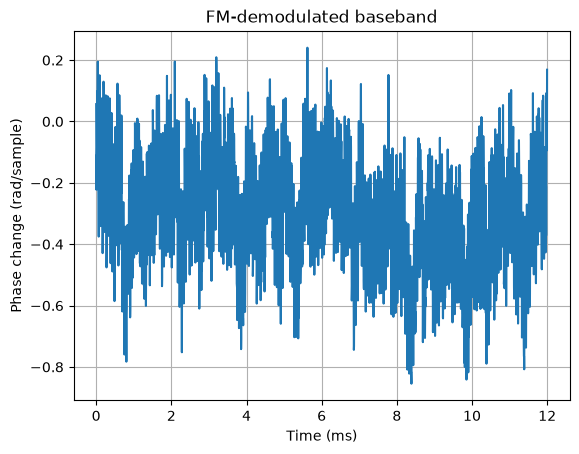

In [4]:
n = 3000
t = np.arange(n) / fs

plt.plot(t * 1000, fm_demod[:n])
plt.xlabel("Time (ms)")
plt.ylabel("Phase change (rad/sample)")
plt.title("FM-demodulated baseband")
plt.grid()
plt.show()

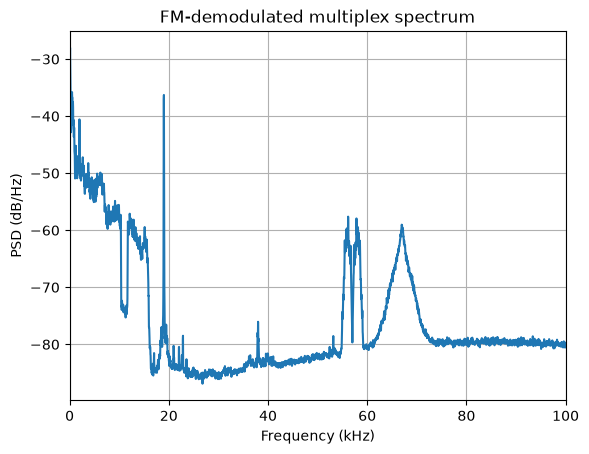

In [5]:
f, pxx = signal.welch(
    fm_demod,
    fs=fs,
    nperseg=8192
)

pxx_db = 10 * np.log10(pxx + 1e-20)

plt.plot(f / 1000, pxx_db)
plt.xlim(0, 100)

plt.xlabel("Frequency (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("FM-demodulated multiplex spectrum")
plt.grid()
plt.show()

In [6]:
## Isolate mono audio

audio_cutoff = 15_000

sos = signal.butter(
    6,
    audio_cutoff,
    btype="lowpass",
    fs=fs,
    output="sos"
)

audio = signal.sosfilt(sos, fm_demod)


audio = audio - np.mean(audio)  ## remove dc




In [7]:
## decimate

audio_50k = signal.resample_poly(
    audio,
    up=1,
    down=5
)

audio_fs = 50_000

print("Audio samples:", len(audio_50k))
print("Audio duration:", len(audio_50k) / audio_fs, "s")

Audio samples: 200000
Audio duration: 4.0 s


In [8]:
peak = np.max(np.abs(audio_50k))

if peak > 0:
    audio_50k = audio_50k / peak

audio_int16 = np.int16(
    np.clip(audio_50k, -1, 1) * 32767
)

In [10]:
output_path = Path("../../outputs/runs/fm_demod_audio.wav")

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

wavfile.write(
    output_path,
    audio_fs,
    audio_int16
)

print("Saved:", output_path.resolve())

Saved: C:\_VAULT\Techhh\IQWAV\outputs\runs\fm_demod_audio.wav
